Setup

In [ ]:
import keras
from keras import layers, ops, KerasTensor, random
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import numpy as np
import glob
from PIL import Image

os.environ["KERAS_BACKEND"] = "tensorflow"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Process images

In [ ]:
imageScale = (32,32)  # divisible by 4
directory = '/content/drive/MyDrive/university_logo/'

fileList = []
for filename in os.listdir(directory):
    fileList.append(directory + filename)

# FIX: force RGBA BEFORE converting to numpy
x = np.array([
    np.array(Image.open(fname).convert("RGBA").resize(imageScale))
    for fname in fileList
])

print(x.shape)   # (N, 32, 32, 4)

inputShape = (imageScale[0], imageScale[1], 4)


(835, 32, 32, 4)


Set seeds

In [ ]:
np.random.seed(0)
tf.random.set_seed(0)

Train and test split

In [ ]:
trainingSize = int(x.shape[0]*0.8) # 80-20ish train-test split
x_train = x[:trainingSize]
x_test = x[trainingSize:]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
print ("Training shape: "+str(x_train.shape))
print ("Testing shape: "+str(x_test.shape))

Training shape: (668, 32, 32, 4)
Testing shape: (167, 32, 32, 4)


Define VAE

In [ ]:
batchSize = 32
latent_dims = 128
beta = 0.01

def sample_vae(mean: KerasTensor, log_var: KerasTensor, latent_dims) -> KerasTensor:
    std_dev = ops.exp(0.5 * log_var)
    batch = ops.shape(mean)[0]
    eps = tf.random.normal(shape=(batch, latent_dims))
    z = mean + eps * std_dev
    return z, mean, log_var

class VAE(keras.Model):
    def __init__(self, latent_dims=128):
        super().__init__()
        self.latent_dims = latent_dims

        self.encoder = keras.Sequential([
            layers.Input(shape=(inputShape[0], inputShape[1], inputShape[2])),

            layers.Conv2D(32, 3, strides=2, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),

            layers.Conv2D(64, 3, strides=2, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),

            layers.Conv2D(128, 3, strides=2, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),

            layers.Flatten(),
            layers.Dense(512, use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),

            layers.Dense(2 * latent_dims),
        ])
        self.encoder.summary()

        feat_shape = (inputShape[0] // 8, inputShape[1] // 8, 128)

        self.decoder = keras.Sequential([
            layers.Input(shape=(latent_dims,)),

            layers.Dense(feat_shape[0] * feat_shape[1] * 256, use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),

            layers.Reshape((feat_shape[0], feat_shape[1], 256)),

            layers.Conv2DTranspose(256, 3, strides=2, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),

            layers.Conv2DTranspose(128, 3, strides=2, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),

            layers.Conv2DTranspose(64, 3, strides=2, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),

            layers.Conv2DTranspose(32, 3, strides=1, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),

            layers.Conv2DTranspose(inputShape[2], 3, strides=1, padding="same", activation="sigmoid"),
        ])
        self.decoder.summary()

    def call(self, x):
        x = self.encoder(x)
        log_var, mean = keras.ops.split(x, 2, axis=-1)
        z, mean, log_var = sample_vae(mean, log_var, self.latent_dims)
        recon = self.decoder(z)
        return recon, z, mean, log_var

class Trainer(keras.Model):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_term_tracker = keras.metrics.Mean(name="kl_term")
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")

    @property
    def metrics(self):
        return [self.reconstruction_loss_tracker, self.kl_term_tracker, self.total_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            x = ops.reshape(data, (-1, inputShape[0], inputShape[1], inputShape[2]))
            x_hat, _, mean, log_var = self.model(x)

            bce = keras.losses.binary_crossentropy(x, x_hat)
            recon_loss = ops.mean(ops.sum(bce, axis=(1, 2)))

            kl_term = -0.5 * ops.mean(
                ops.sum(1 + log_var - ops.square(mean) - ops.exp(log_var), axis=-1)
            )

            loss = recon_loss + beta * kl_term

        gradients = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))

        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_term_tracker.update_state(kl_term)
        self.total_loss_tracker.update_state(loss)

        return {
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_term": self.kl_term_tracker.result(),
            "total_loss": self.total_loss_tracker.result(),
        }

vae = VAE(latent_dims=latent_dims)
t = Trainer(vae)
t.compile(optimizer=keras.optimizers.Adam(learning_rate=2e-4))
history = t.fit(x_train, epochs=80, batch_size=batchSize)

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 32)     │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 8, 8, 64)       │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 4, 4, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 512)            │     1,048,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,276,160 (4.87 MB)

 Trainable params: 1,274,688 (4.86 MB)

 Non-trainable params: 1,472 (5.75 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 4096)           │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_8 (Reshape)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_32             │ (None, 8, 8, 256)      │       589,824 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_33             │ (None, 16, 16, 128)    │       294,912 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_34             │ (None, 32, 32, 64)     │        73,728 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_35             │ (None, 32, 32, 32)     │        18,432 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_36             │ (None, 32, 32, 4)      │         1,156 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,520,644 (5.80 MB)

 Trainable params: 1,511,492 (5.77 MB)

 Non-trainable params: 9,152 (35.75 KB)

Epoch 1/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 503ms/step - kl_term: 0.7832 - reconstruction_loss: 705.8889 - total_loss: 705.8967
Epoch 2/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 545ms/step - kl_term: 2.0174 - reconstruction_loss: 675.7402 - total_loss: 675.7604
Epoch 3/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 440ms/step - kl_term: 3.7112 - reconstruction_loss: 657.7438 - total_loss: 657.7810
Epoch 4/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 545ms/step - kl_term: 107.6155 - reconstruction_loss: 613.4606 - total_loss: 614.5369
Epoch 5/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 544ms/step - kl_term: 186.4134 - reconstruction_loss: 572.8302 - total_loss: 574.6944
Epoch 6/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 541ms/step - kl_term: 199.0854 - reconstruction_loss: 557.4402 - total_loss: 559.4310
Epoch 7/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 580ms/step - kl_term: 170.7146 - reconstruction_loss: 548.2369 - total_loss: 549.9440
Epoch 8/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 508ms/step - kl_term: 137.8584 - reconstruction_loss: 539.9886 - tot

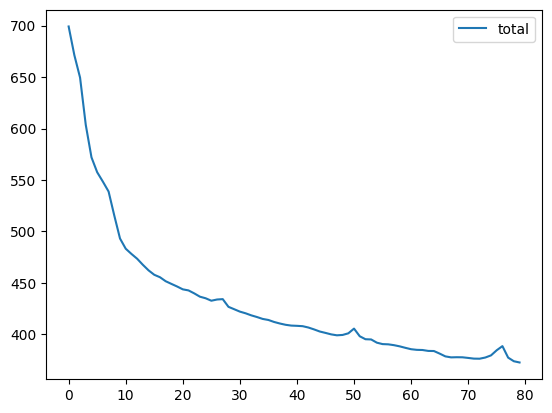

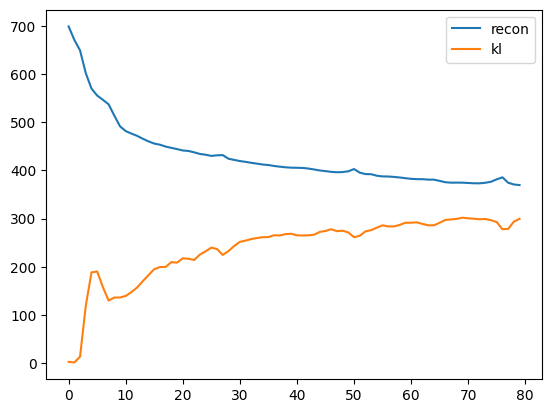

In [ ]:
plt.plot(t.history.history["total_loss"], label="total")
plt.legend()
plt.show()
plt.plot(t.history.history["reconstruction_loss"], label="recon")
plt.plot(t.history.history["kl_term"], label="kl")
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step


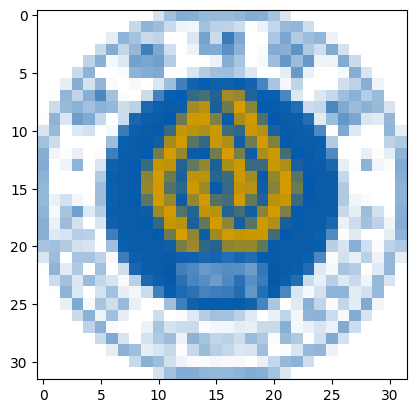

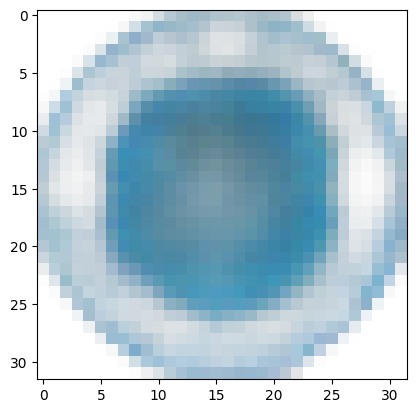

In [ ]:
#Visualize reconstruction train
i = 0
recon, _, _, _ = vae.predict(x_train[i].reshape(-1, inputShape[0], inputShape[1], inputShape[2]))
plt.imshow(x_train[i])
plt.show()
plt.imshow(recon.reshape((inputShape[0], inputShape[1], inputShape[2])))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


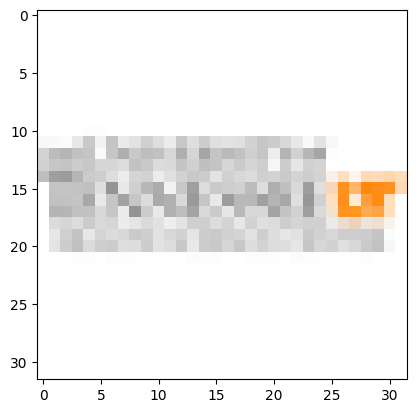

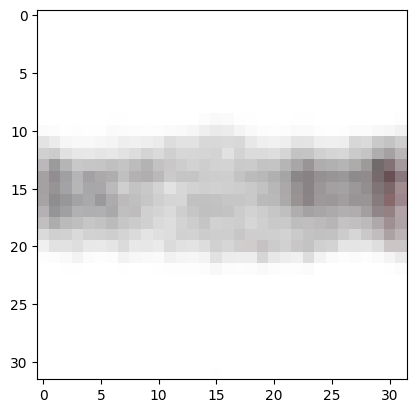

In [ ]:
#Visualize reconstruction test
i = 68
recon, _, _, _ = vae.predict(x_test[i].reshape(-1, inputShape[0], inputShape[1], inputShape[2]))
plt.imshow(x_test[i])
plt.show()
plt.imshow(recon.reshape((inputShape[0], inputShape[1], inputShape[2])))

In [ ]:
# Get test reconstruction average loss
recon, _, _, _  = vae.predict(x_test.reshape(-1, inputShape[0], inputShape[1], inputShape[2]))
reconLoss = ops.sum((x_test-recon)**2, axis=(1,2))
print (ops.mean(reconLoss))

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step
tf.Tensor(33.148453, shape=(), dtype=float32)


21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 203ms/step


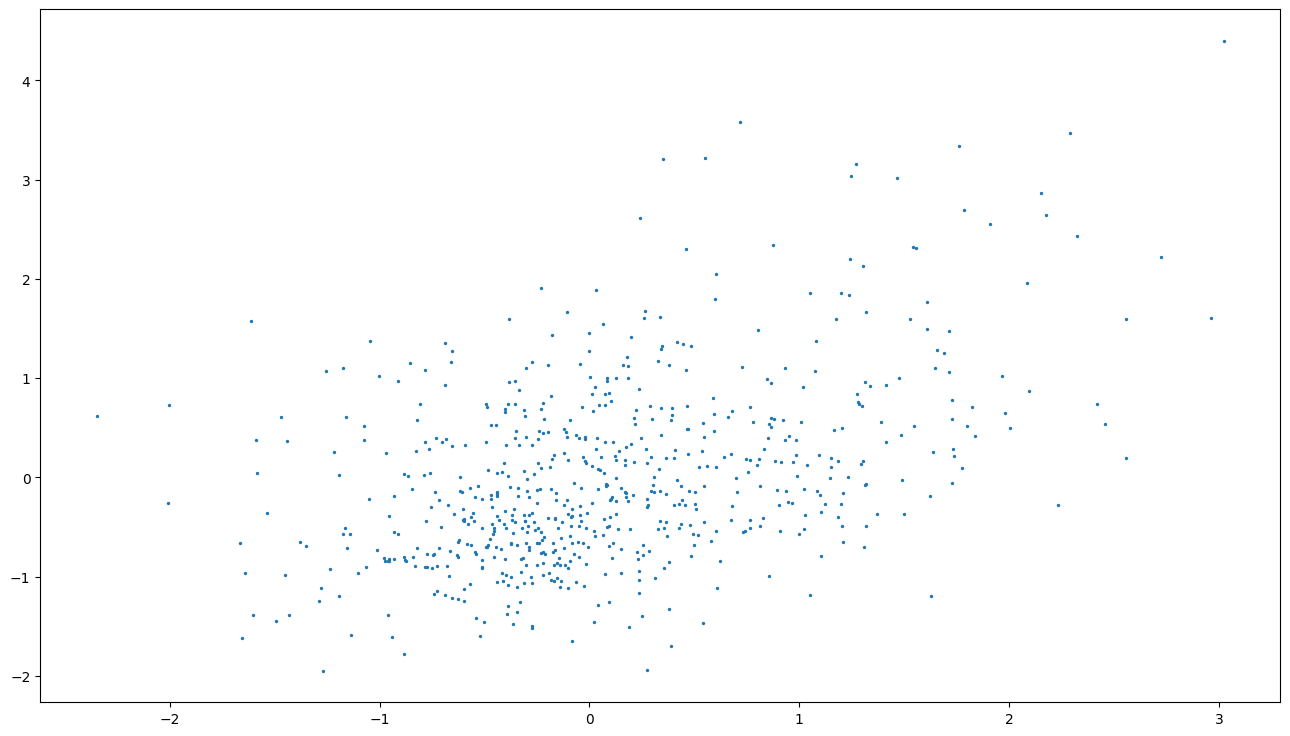

In [ ]:
# now visualize the embedding space (only works with a 2D embedding)
def compute_embeddings(model, x_train):
	_, latents, _, _ = model.predict(x_train.reshape(-1, inputShape[0], inputShape[1], inputShape[2]))
	return latents


def plot(latents):
	plt.show()
	plt.figure(figsize=(16, 9))
	plt.scatter(latents[:, 0], latents[:, 1], s=2, alpha=1)

latents = compute_embeddings(vae, x_train)
plot(latents)

Latent shape: (668, 128)
Cluster counts: {np.int32(0): np.int64(56), np.int32(1): np.int64(90), np.int32(2): np.int64(117), np.int32(3): np.int64(46), np.int32(4): np.int64(40), np.int32(5): np.int64(44), np.int32(6): np.int64(143), np.int32(7): np.int64(41), np.int32(8): np.int64(40), np.int32(9): np.int64(51)}


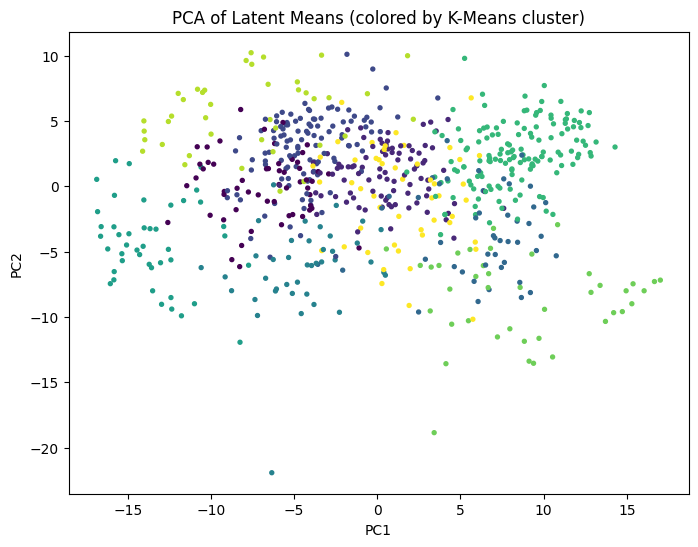

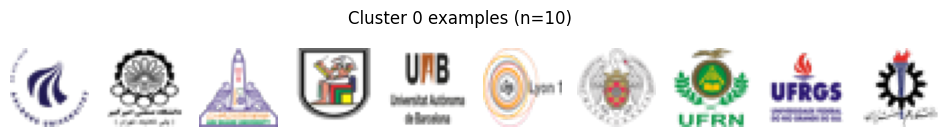

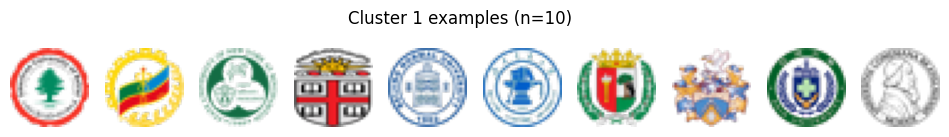

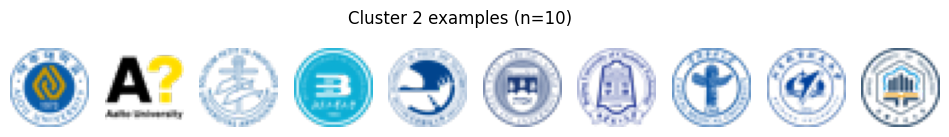

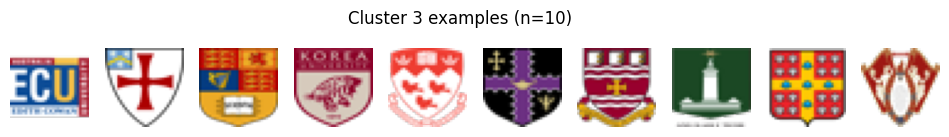

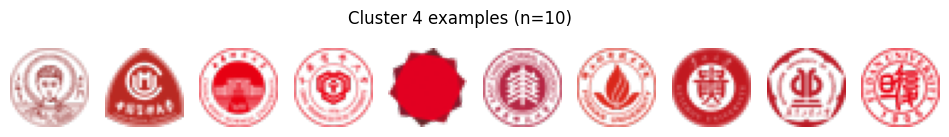

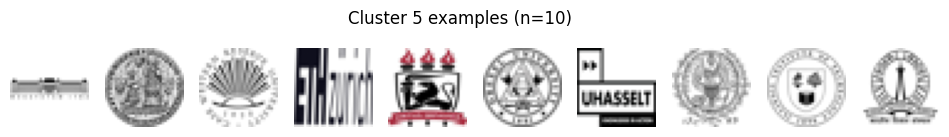

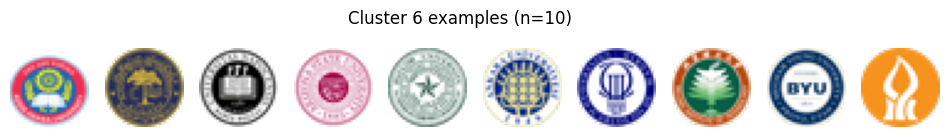

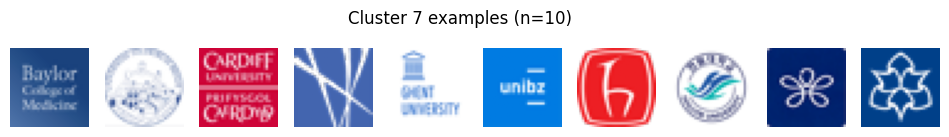

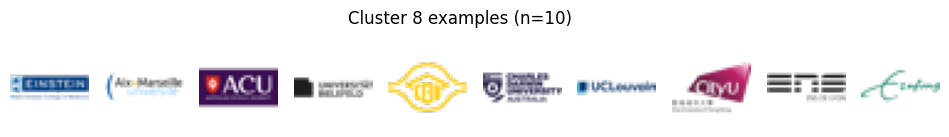

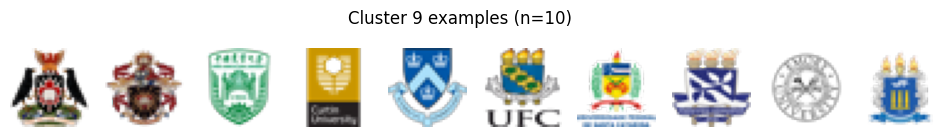

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def get_latent_means(vae, x, batch_size=256):
    means = []
    for i in range(0, len(x), batch_size):
        xb = x[i:i+batch_size]
        enc = vae.encoder(xb)
        log_var, mean = keras.ops.split(enc, 2, axis=-1)
        means.append(np.array(mean))
    return np.concatenate(means, axis=0)

Z = get_latent_means(vae, x_train, batch_size=256)
print("Latent shape:", Z.shape)
K = 10
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = kmeans.fit_predict(Z)

unique, counts = np.unique(labels, return_counts=True)
print("Cluster counts:", dict(zip(unique, counts)))
pca = PCA(n_components=2, random_state=42)
Z2 = pca.fit_transform(Z)

plt.figure(figsize=(8,6))
plt.scatter(Z2[:,0], Z2[:,1], c=labels, s=8)
plt.title("PCA of Latent Means (colored by K-Means cluster)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
def show_cluster_examples(x, labels, k, n=10):
    idx = np.where(labels == k)[0]
    if len(idx) == 0:
        print(f"Cluster {k} is empty.")
        return
    pick = idx[:n]

    plt.figure(figsize=(n*1.2, 1.6))
    for j, i in enumerate(pick):
        plt.subplot(1, len(pick), j+1)
        plt.imshow(x[i])
        plt.axis("off")
    plt.suptitle(f"Cluster {k} examples (n={len(pick)})")
    plt.show()

for k in range(K):
    show_cluster_examples(x_train, labels, k, n=10)
